<a href="https://colab.research.google.com/github/hanzalaakeel/NIAI_Cohort_2026/blob/main/NETSOL_AI_ML_Tasks/Distributions_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv('/content/Pakistani_Diabetes_Dataset.csv')

# Quick overview
df.head()

,Age,Gender,Rgn,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1


📋 List of Attributes:

Age

Gender

Rgn (Region)

wt (Weight)

BMI (Body Mass Index)

wst (Waist Circumference)

sys (Systolic Blood Pressure)

dia (Diastolic Blood Pressure)

his (Family History of Diabetes)

A1c (HbA1c – Average Blood Sugar)

B.S.R (Blood Sugar Random)

vision (Vision Problems)

Exr (Exercise)

dipsia (Excessive Thirst)

uria (Frequent Urination)

Dur (Duration of Diabetes)

neph (Nephropathy – Kidney Disease)

HDL (Good Cholesterol)

Outcome (Diabetes Status)

2. Understanding Dataset:

In [3]:
df.info()
df.describe()

# Target variable
df['Outcome'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Age      912 non-null    float64
 1   Gender   912 non-null    int64  
 2   Rgn      912 non-null    int64  
 3   wt       912 non-null    float64
 4   BMI      912 non-null    float64
 5   wst      912 non-null    float64
 6   sys      912 non-null    int64  
 7   dia      912 non-null    int64  
 8   his      912 non-null    int64  
 9   A1c      912 non-null    float64
 10  B.S.R    912 non-null    int64  
 11  vision   912 non-null    int64  
 12  Exr      912 non-null    int64  
 13  dipsia   912 non-null    int64  
 14  uria     912 non-null    int64  
 15  Dur      912 non-null    float64
 16  neph     912 non-null    int64  
 17  HDL      912 non-null    int64  
 18  Outcome  912 non-null    int64  
dtypes: float64(6), int64(13)
memory usage: 135.5 KB


,count
Outcome,
1,486
0,426


Outcome - Diabetes (1 = Yes, 0 = No)

Binary variables: Gender, Outcome, neph, Exr, etc.

Continuous: Age, BMI, A1c, HDL

3. Bernoulli Distribution:

👉 Used for binary outcomes (0 or 1)
👉 Apply on: Outcome

Only two outcomes: Success / Failure

Parameter: p = probability of success

Probability of Diabetes: 0.5328947368421053


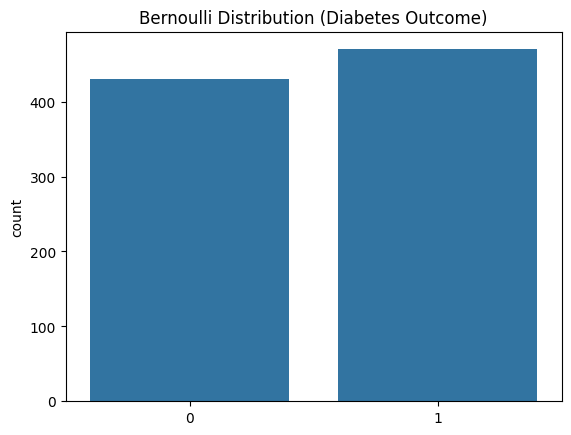

In [14]:
# Probability of having diabetes
p = df['Outcome'].mean()

print("Probability of Diabetes:", p)

# Bernoulli samples
bernoulli_sample = stats.bernoulli.rvs(p, size=900)

# Visualization
sns.countplot(x=bernoulli_sample)
plt.title("Bernoulli Distribution (Diabetes Outcome)")
plt.show()

4. Binomial Distribution:

👉 Used for number of successes in n trials

📘 Example:

“How many diabetic patients in 10 people?”

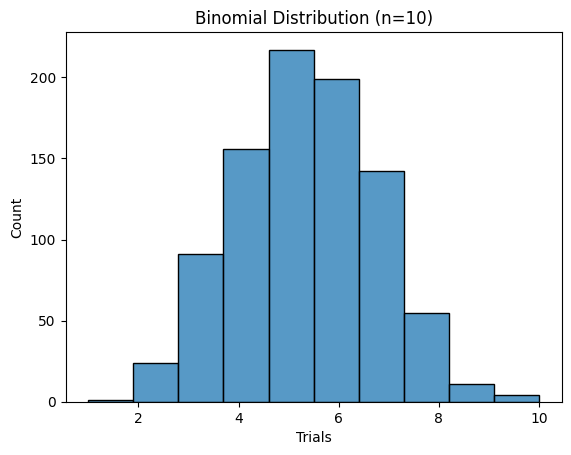

In [16]:
n = 10  # trials
p = df['Outcome'].mean()

binomial_sample = stats.binom.rvs(n, p, size=900)

sns.histplot(binomial_sample, bins=10, kde=False)
plt.title("Binomial Distribution (n=10)")
plt.xlabel("Trials")
plt.show()

5. Normal Distribution:

👉 Used for continuous variables

📘 Apply on:
Age
BMI
A1c

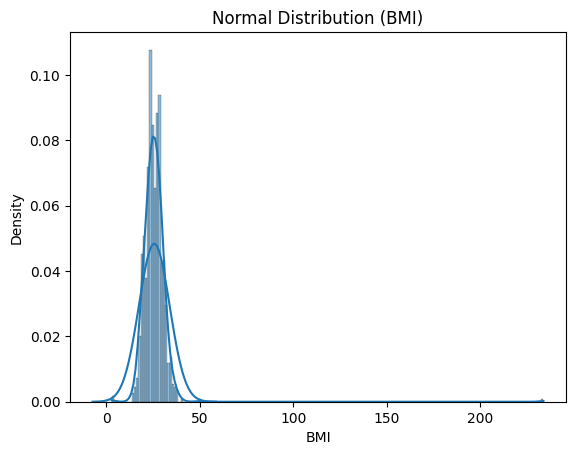

In [6]:
# Example: BMI
mean = df['BMI'].mean()
std = df['BMI'].std()

x = np.linspace(mean-4*std, mean+4*std, 100)

pdf = stats.norm.pdf(x, mean, std)

plt.plot(x, pdf)
sns.histplot(df['BMI'], kde=True, stat="density")
plt.title("Normal Distribution (BMI)")
plt.show()

Log Transformation:

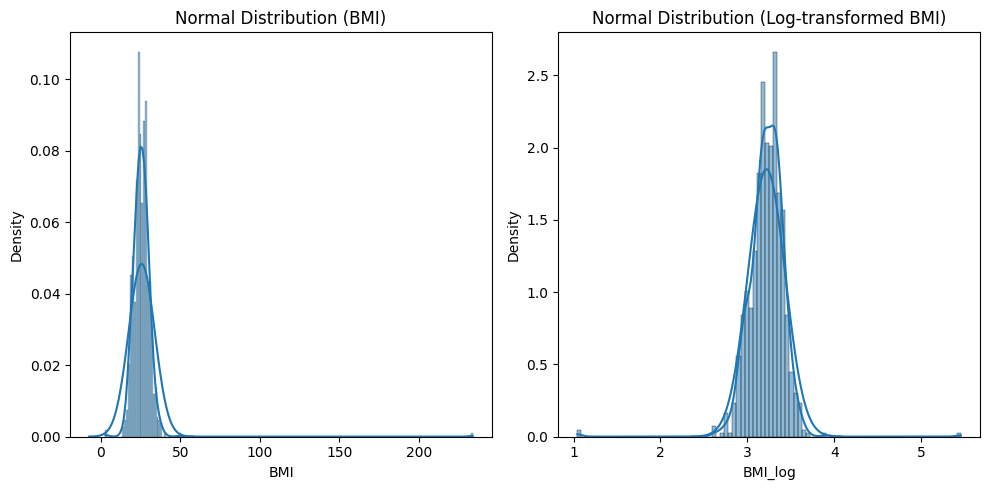

In [33]:
df['BMI_log'] = np.log(df['BMI'])

mean_log = df['BMI_log'].mean()
std_log = df['BMI_log'].std()

x_log = np.linspace(mean_log - 4 * std_log, mean_log + 4 * std_log, 100)
pdf_log = stats.norm.pdf(x_log, mean_log, std_log)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf)
sns.histplot(df['BMI'], kde=True, stat="density")
plt.title("Normal Distribution (BMI)")

plt.subplot(1, 2, 2)
plt.plot(x_log, pdf_log)
sns.histplot(df['BMI_log'], kde=True, stat="density")
plt.title("Normal Distribution (Log-transformed BMI)")

plt.tight_layout()
plt.show()

6. Poisson Distribution

👉 Used for count of events in fixed interval

📘 Example:

Number of complications like neph (nephropathy)

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2132/4258131391.py:25: SyntaxWarning: invalid escape sequence '\l'
  label=f'Poisson PMF ($\lambda$={lambda_val:.2f})')


Calculated Lambda (Mean Duration): 3.87


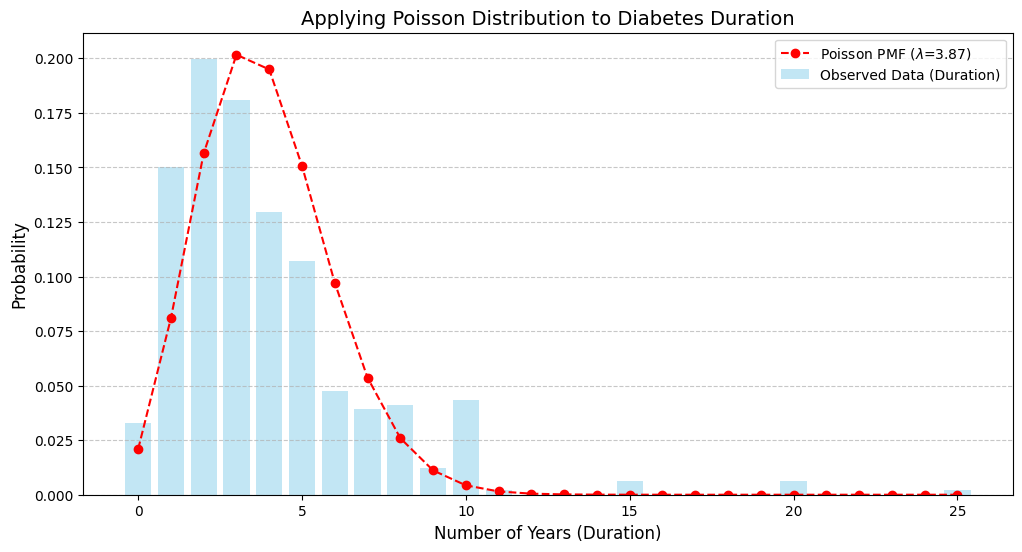

In [30]:
diabetic_df = df[df['Outcome'] == 1]
duration_data = diabetic_df['Dur'].astype(int)

# Calculate lambda (mean duration)
lambda_val = duration_data.mean()
print(f"Calculated Lambda (Mean Duration): {lambda_val:.2f}")

# Calculate observed probabilities
observed_probs = duration_data.value_counts(normalize=True).sort_index()

# Generate theoretical Poisson PMF
x_range = np.arange(0, duration_data.max() + 1)

theoretical_pmf = stats.poisson.pmf(x_range, lambda_val)

# Visualization
plt.figure(figsize=(12, 6))

# Plot actual data
plt.bar(observed_probs.index, observed_probs.values, alpha=0.5,
        color='skyblue', label='Observed Data (Duration)')

# Plot Poisson PMF
plt.plot(x_range, theoretical_pmf, 'ro--', markersize=6,
         label=f'Poisson PMF ($\lambda$={lambda_val:.2f})')

plt.title('Applying Poisson Distribution to Diabetes Duration', fontsize=14)
plt.xlabel('Number of Years (Duration)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

7. Uniform Distribution

👉 All values equally likely

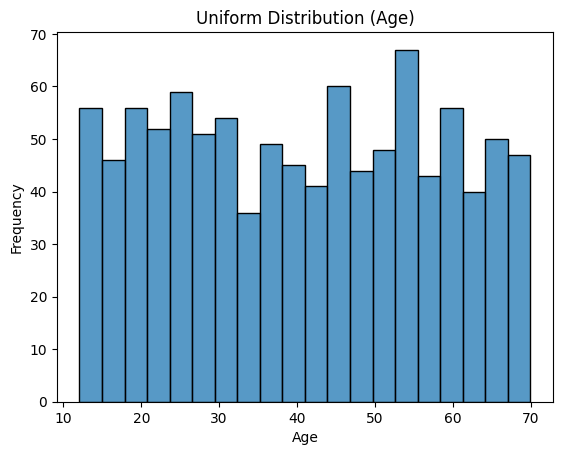

In [36]:
low = df['Age'].min()
high = df['Age'].max()

uniform_sample = stats.uniform.rvs(loc=low, scale=high-low, size=1000)

sns.histplot(uniform_sample, bins=20)
plt.title("Uniform Distribution (Age)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

8. Exponential Distribution

👉 Time between events

📘 Example:

Use Dur (duration of diabetes)

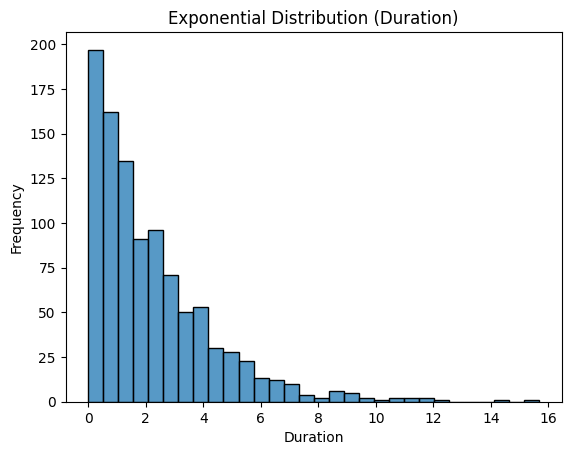

In [37]:
lambda_ = 1 / df['Dur'].mean()

exp_sample = stats.expon.rvs(scale=1/lambda_, size=1000)

sns.histplot(exp_sample, bins=30)
plt.title("Exponential Distribution (Duration)")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

9. t-Distribution

👉 Used when:

Small samples

Unknown population variance or std

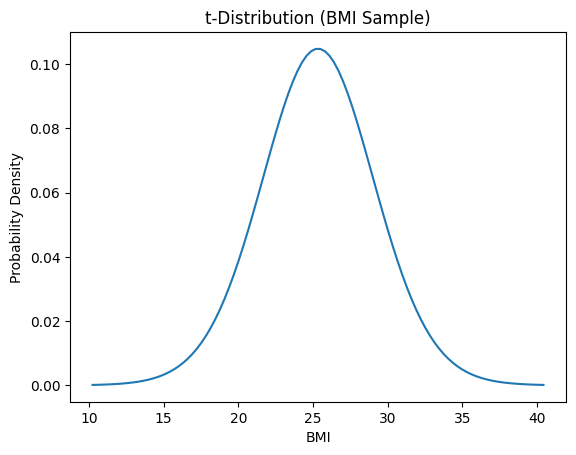

In [38]:
sample = df['BMI'].sample(30)

mean = sample.mean()
std = sample.std()
n = len(sample)

x = np.linspace(mean-4*std, mean+4*std, 100)

t_pdf = stats.t.pdf(x, df=n-1, loc=mean, scale=std)

plt.plot(x, t_pdf)
plt.title("t-Distribution (BMI Sample)")
plt.xlabel("BMI")
plt.ylabel("Probability Density")
plt.show()

Grand Comparison of Distributions:

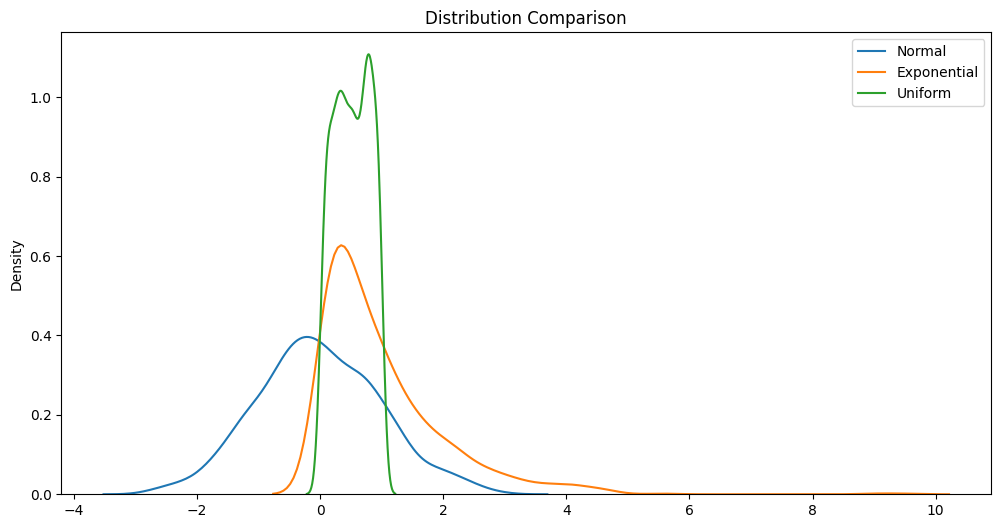

In [12]:
plt.figure(figsize=(12,6))

# Normal
sns.kdeplot(stats.norm.rvs(size=1000), label="Normal")

# Exponential
sns.kdeplot(stats.expon.rvs(size=1000), label="Exponential")

# Uniform
sns.kdeplot(stats.uniform.rvs(size=1000), label="Uniform")

plt.legend()
plt.title("Distribution Comparison")
plt.show()

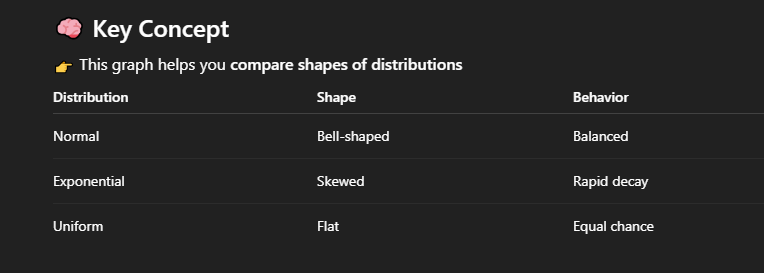

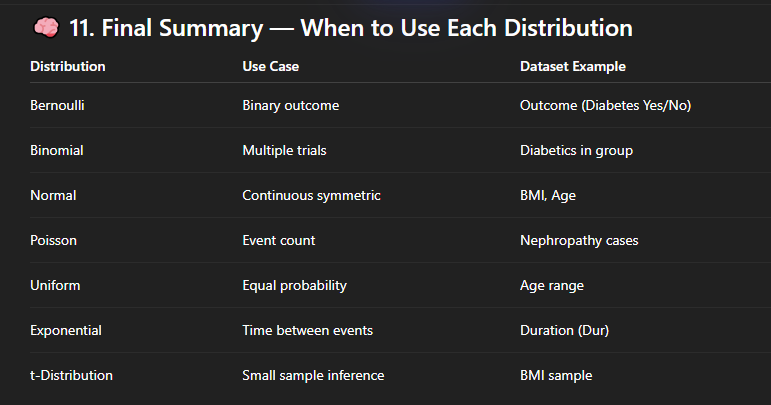